The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Pooled (weighted) % tuned (A+B) by mouse/condition:
mouse         condition  total_cells  tuned_AB   pct_AB  pct_AB_%
 JAL3 barrier_post_flip          253       2.0 0.007905  0.790514
 JAL3  barrier_pre_flip          257       7.0 0.027237  2.723735
 JAL4 barrier_post_flip         1004      69.0 0.068725  6.872510
 JAL4  barrier_pre_flip         1045      98.0 0.093780  9.377990
 JAL5 barrier_post_flip          471       8.0 0.016985  1.698514
 JAL5  barrier_pre_flip          462       8.0 0.017316  1.731602
 JAL6 barrier_post_flip          453      38.0 0.083885  8.388521
 JAL6  barrier_pre_flip          462      45.0 0.097403  9.740260
 JAL7 barrier_post_flip          953      35.0 0.036726  3.672613
 JAL7  barrier_pre_flip          959      44.0 0.045881  4.588113
 JAL8 barrier_post_flip          600      34.0 0.056667  5.666667
 JAL8  barrier_pre_flip          603      22.0 0.036484  3.648425
Saved figure to /ceph/branco/Laurence/thesis/efizz_chapter/subgoal_cells_by_mouse_pre_pos

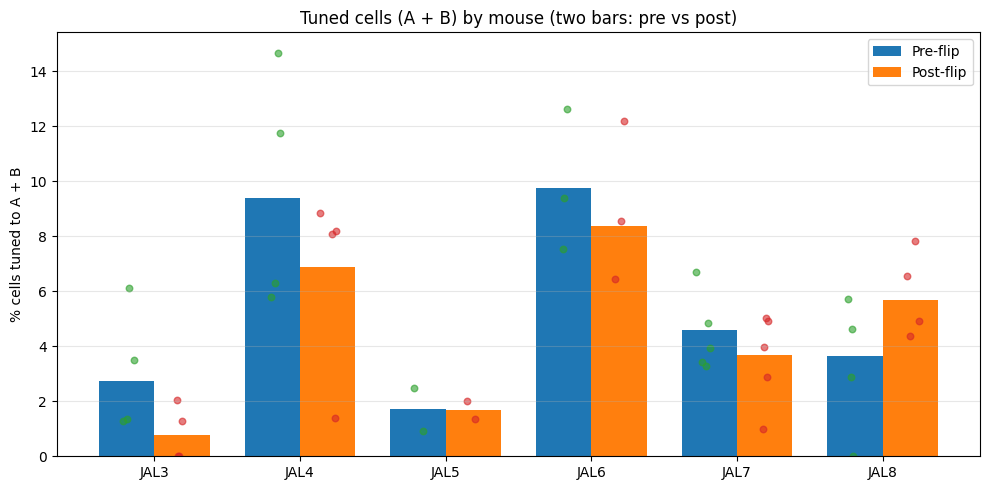

In [3]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SAVE_ROOT = Path(r"/ceph/branco/Jasmine_Laurence/rayleigh_analysis/Top2_TunED")
CSV_PATH = SAVE_ROOT / "session_df_tuning_summary.csv"

MOUSE_ORDER = ["JAL3", "JAL4", "JAL5", "JAL6", "JAL7", "JAL8"]
COND_ORDER = ["barrier_pre_flip", "barrier_post_flip"]
COND_LABEL = {"barrier_pre_flip": "Pre-flip", "barrier_post_flip": "Post-flip"}


def session_to_mouse(session: str) -> str:
    """
    Extract mouse ID from session strings like:
      JAL6_flip7_1apr -> JAL6
      JAL005_8thSept  -> JAL5
      JAL4_3rdSept    -> JAL4
    """
    m = re.match(r"^(JAL)(\d+)", str(session))
    if not m:
        return "UNKNOWN"
    num = int(m.group(2))  # strips leading zeros
    return f"JAL{num}"


def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"CSV not found: {path}")
    df = pd.read_csv(path)

    required = {"session", "condition", "total_cells", "pct_A", "pct_B"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV missing columns: {sorted(missing)}")

    return df


def compute_pct_ab(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert pct_A/pct_B into tuned counts then back into pct(A+B),
    keeping it explicitly as 'percentage of all cells'.
    """
    out = df.copy()
    out["mouse"] = out["session"].map(session_to_mouse)

    # session-level tuned counts (not necessarily integer in source; use float counts)
    out["nA"] = out["pct_A"] * out["total_cells"]
    out["nB"] = out["pct_B"] * out["total_cells"]
    out["pct_AB"] = (out["nA"] + out["nB"]) / out["total_cells"]

    return out


def pooled_by_mouse_condition(df: pd.DataFrame) -> pd.DataFrame:
    """
    Weighted (pooled) percentage across sessions:
      pct_AB_mouse = sum(nA+nB) / sum(total_cells)
    """
    g = (
        df.groupby(["mouse", "condition"], as_index=False)
        .agg(total_cells=("total_cells", "sum"), tuned_AB=("nA", "sum"))
    )
    # tuned_AB currently sum(nA); add nB too
    # (we aggregated nA only above; easiest is re-aggregate both properly)
    # Let's do it correctly here:
    g = (
        df.groupby(["mouse", "condition"], as_index=False)
        .agg(
            total_cells=("total_cells", "sum"),
            tuned_AB=("nA", "sum"),
            tuned_B=("nB", "sum"),
        )
    )
    g["tuned_AB"] = g["tuned_AB"] + g["tuned_B"]
    g["pct_AB"] = g["tuned_AB"] / g["total_cells"]
    return g[["mouse", "condition", "total_cells", "tuned_AB", "pct_AB"]]


def plot_two_bars_per_mouse(mouse_cond: pd.DataFrame, session_df: pd.DataFrame):
    # restrict to the mice we care about
    mouse_cond = mouse_cond[mouse_cond["mouse"].isin(MOUSE_ORDER)].copy()

    # make sure all (mouse, condition) exist; fill missing with 0
    idx = pd.MultiIndex.from_product([MOUSE_ORDER, COND_ORDER], names=["mouse", "condition"])
    mouse_cond = mouse_cond.set_index(["mouse", "condition"]).reindex(idx).reset_index()
    mouse_cond["pct_AB"] = mouse_cond["pct_AB"].fillna(0.0)

    x = np.arange(len(MOUSE_ORDER))
    width = 0.38

    pre = mouse_cond[mouse_cond["condition"] == "barrier_pre_flip"]["pct_AB"].to_numpy() * 100
    post = mouse_cond[mouse_cond["condition"] == "barrier_post_flip"]["pct_AB"].to_numpy() * 100

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, pre, width, label="Pre-flip")
    ax.bar(x + width / 2, post, width, label="Post-flip")

    # Optional: overlay session-level points (jittered) so you can see within-mouse variation
    rng = np.random.default_rng(0)
    sess = session_df.copy()
    sess = sess[sess["mouse"].isin(MOUSE_ORDER)]
    sess["mouse_idx"] = sess["mouse"].map({m: i for i, m in enumerate(MOUSE_ORDER)})
    for cond, offset in [("barrier_pre_flip", -width / 2), ("barrier_post_flip", +width / 2)]:
        sub = sess[sess["condition"] == cond]
        if len(sub) == 0:
            continue
        jitter = rng.normal(0, 0.04, size=len(sub))
        xs = sub["mouse_idx"].to_numpy() + offset + jitter
        ys = (sub["pct_AB"].to_numpy() * 100)
        ax.scatter(xs, ys, s=22, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(MOUSE_ORDER)
    ax.set_ylabel("% cells tuned to A + B")
    ax.set_title("Tuned cells (A + B) by mouse (two bars: pre vs post)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.tight_layout()
    
    # SAve fig
    save_path = r"/ceph/branco/Laurence/thesis/efizz_chapter/subgoal_cells_by_mouse_pre_post.eps"
    fig.savefig(save_path, format="eps", dpi=300, bbox_inches="tight")

    print(f"Saved figure to {save_path}")
    
    
    plt.show()


def main():
    df = load_csv(CSV_PATH)
    df = compute_pct_ab(df)

    # pooled % per mouse per condition
    mouse_cond = pooled_by_mouse_condition(df)

    # print table you can sanity check / upload
    print("\nPooled (weighted) % tuned (A+B) by mouse/condition:")
    pretty = mouse_cond.copy()
    pretty["pct_AB_%"] = pretty["pct_AB"] * 100
    print(pretty.sort_values(["mouse", "condition"]).to_string(index=False))

    plot_two_bars_per_mouse(mouse_cond, df)


if __name__ == "__main__":
    main()